# Dupor (2023) household: minimal demo

Two exercises using the Dupor (2023) household block in **partial equilibrium**:

1. **Stationary distribution of consumption and labor supply** — using the fast eigenvector method (`compute_pe_steady_state`).
2. **Partial replication of Figure 5** — impulse responses of consumption *C* and asset holdings *A* in the region that receives the shock, using HARK's sequence-space Jacobian (SSJ) machinery.

For now we focus on the region hit by the shock; the two-region GE block (intermediate firms with Calvo pricing, regional mutual funds, monetary policy) is left for future work.


In [1]:
import os, sys, importlib.util, time
import numpy as np
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("dupor_minimal_demo.ipynb")) or os.getcwd()

# Make sure HARK's internal `from interpolation import interp` doesn't get
# shadowed by the local `interpolation.py` in this folder.
sys.path = [p for p in sys.path if os.path.abspath(p) != os.path.abspath(HERE)]

import HARK
_v = tuple(int(x) for x in HARK.__version__.split(".")[:2])
assert _v >= (0, 17), f"This demo requires econ-ark >= 0.17 (found {HARK.__version__})"

def _load_local(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_load_local("rewards", os.path.join(HERE, "rewards.py"))
cl = _load_local("ConsLaborModelSep", os.path.join(HERE, "ConsLaborModel copy.py"))
LaborIntMargSepMrkvConsumerType = cl.LaborIntMargSepMrkvConsumerType

# Build + solve the infinite-horizon Markov household with default calibration.
# (Div = 0 by default in this PE demo; the dividend mechanism awaits the
# intermediate-firm block.)
agent = LaborIntMargSepMrkvConsumerType(cycles=0, T_cycle=1)
agent.solve()
print(f"Agent solved. MrkvCount = {agent.MrkvArray.shape[0]}, Rfree = {float(agent.Rfree[0]):.4f}.")


Agent solved. MrkvCount = 7, Rfree = 1.0099.


## Exercise 1 &mdash; Stationary distribution of consumption and labor supply

Using the eigenvector method (`compute_pe_steady_state`), we construct the joint transition operator over the `(bLvl, Mrkv)` state space and find its dominant left eigenvector. The ergodic distribution is the natural object for cross-sectional analysis: integrating policies against it yields steady-state moments more accurately than long Monte-Carlo simulation, in a fraction of the time.

The plots below show the ergodic densities of consumption *c* and labor supply *h*, computed as weighted histograms over the joint distribution `erg_dstn` and the corresponding policy grids `cPol_Grid`, `LbrPol_Grid`. The right panel shows the marginal ergodic mass over bank balances $b$ for reference.


Non-stochastic steady state computed in 0.12s (Nb=200 x M=7 = 1400 joint states)

Steady-state aggregates:
  C_ss = 0.5683
  L_ss = 0.4153
  A_ss = 6.8618
  B_ss = 6.9589


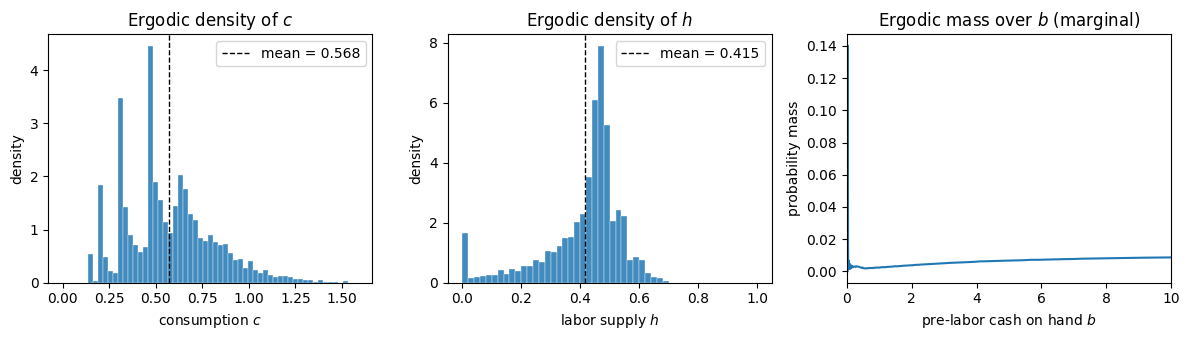

In [2]:
t0 = time.time()
ss = agent.compute_pe_steady_state()
t_ss = time.time() - t0
print(f"Non-stochastic steady state computed in {t_ss:.2f}s "
      f"(Nb={agent.dist_bGrid.size} x M={agent.MrkvArray.shape[0]} = "
      f"{agent.tran_matrix.shape[0]} joint states)")
print()
print("Steady-state aggregates:")
for k, v in ss.items():
    print(f"  {k} = {v:.4f}")

# Ergodic distribution of c and h as mass-weighted histograms over policy values.
weights = agent.erg_dstn.ravel()
c_vals  = agent.cPol_Grid.ravel()
h_vals  = agent.LbrPol_Grid.ravel()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# --- Ergodic density of c ---
c_bins = np.linspace(0, c_vals.max() * 1.05, 60)
axes[0].hist(c_vals, bins=c_bins, weights=weights, density=True,
             alpha=0.85, edgecolor="white", linewidth=0.3)
axes[0].axvline(ss['C_ss'], color='k', lw=1, ls='--',
                label=f"mean = {ss['C_ss']:.3f}")
axes[0].legend()
axes[0].set_title(r"Ergodic density of $c$")
axes[0].set_xlabel(r"consumption $c$")
axes[0].set_ylabel("density")

# --- Ergodic density of h ---
h_bins = np.linspace(0, 1, 51)
axes[1].hist(h_vals, bins=h_bins, weights=weights, density=True,
             alpha=0.85, edgecolor="white", linewidth=0.3)
axes[1].axvline(ss['L_ss'], color='k', lw=1, ls='--',
                label=f"mean = {ss['L_ss']:.3f}")
axes[1].legend()
axes[1].set_title(r"Ergodic density of $h$")
axes[1].set_xlabel(r"labor supply $h$")
axes[1].set_ylabel("density")

# --- Marginal ergodic mass over bLvl (pre-labor cash on hand) ---
b_marginal = agent.erg_dstn.sum(axis=0)
axes[2].plot(agent.dist_bGrid, b_marginal, lw=1.5)
axes[2].set_title(r"Ergodic mass over $b$ (marginal)")
axes[2].set_xlabel(r"pre-labor cash on hand $b$")
axes[2].set_ylabel("probability mass")
axes[2].set_xlim(0, 10)

plt.tight_layout()
plt.show()


## Exercise 2 &mdash; Replication of Figure 5 (region hit by the shock, PE)

Figure 5 of Dupor et al. (2023) shows six impulse responses to a temporary regional government-spending shock. In the paper, the shock is a localised increase in $G_1$ whose peak is calibrated to 1% above steady state; the AR(2) profile is chosen to match the county-level Recovery Act spending path. The full figure shows two regions and six panels (inflation, wages, dividends, consumption, asset holdings, plus the shock itself).

Here we present a **partial-equilibrium analogue** for the shocked region, focusing on the two panels of Figure 5 that come directly from the household block:

* **Consumption** *C* (lower-left panel of Figure 5)
* **Asset holdings** *A* (lower-right panel of Figure 5)

The remaining panels require the intermediate-firm block (for inflation, wages, dividends), which is not yet implemented. As proxies for the fiscal stimulus's effect on household disposable income, we feed in two exogenous time series, both expressed as **percent deviations from steady state**:

* a **lump-sum transfer** shock `Trnsfr` (24 quarters, AR(2) impact profile with $\rho \sim 0.76$), standing in for the direct fiscal-injection channel; and
* a **wage** shock `WageRte` (24 quarters, smaller-amplitude AR(2)-like profile), standing in for the firm-side wage increase that the paper's intermediate-good firms produce in response to higher demand.

Because the SSJ is a first-order object around the steady state, the linearised IRF satisfies **superposition** &mdash; the response to a joint shock is the sum of the responses to each component:

$$
\Delta X_t \;=\; \underbrace{\sum_{s=0}^{T-1} \mathcal{J}^{X,\mathcal{T}}_{t,s}\, \Delta\mathcal{T}_s}_{\text{transfer channel}}
            \;+\; \underbrace{\sum_{s=0}^{T-1} \mathcal{J}^{X,W}_{t,s}\, \Delta W_s}_{\text{wage channel}},
\qquad
\Delta P_s \;=\; \frac{\text{shock}_s}{100} \cdot P_{ss},
\qquad
\frac{\Delta X_t}{X_{ss}} \times 100 \;=\; \text{response in \%}.
$$

The cell below computes both SSJs (passing `solved=True` on the second call so HARK doesn't re-solve the long-run model), plots the two channels separately as a sanity check, and then overlays the combined IRF.


Computing SSJs (T_max = 24) ...


  Trnsfr SSJs in 7.3s (cLvl (24, 24), aLvl (24, 24))


  WageRte SSJs in 1.1s (cLvl (24, 24), aLvl (24, 24))


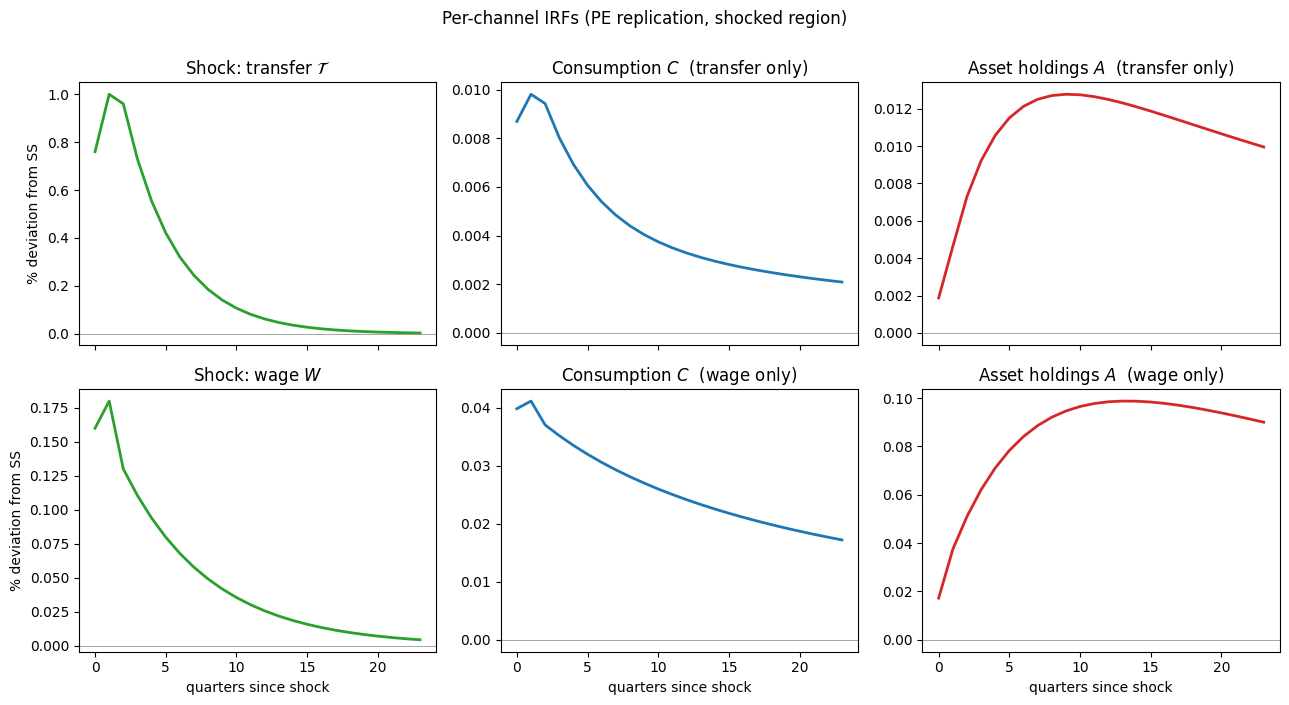

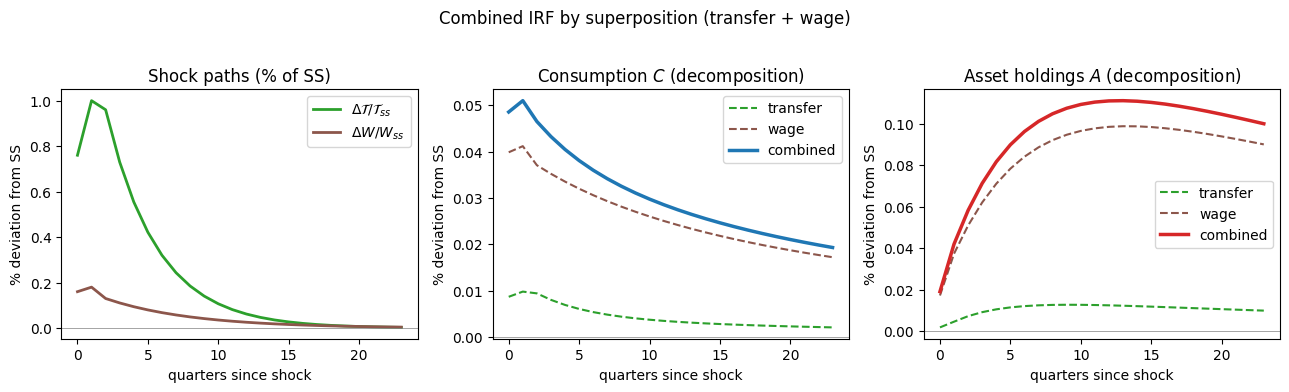


  t   dT (%)   dW (%)   dC_T (%)   dC_W (%)  dC_tot (%)   dA_T (%)   dA_W (%)  dA_tot (%)
  0   0.7600   0.1600     0.0087     0.0399      0.0485     0.0019     0.0172      0.0191
  1   1.0000   0.1800     0.0098     0.0412      0.0510     0.0046     0.0374      0.0420
  2   0.9600   0.1300     0.0094     0.0371      0.0465     0.0073     0.0510      0.0582
  3   0.7296   0.1105     0.0080     0.0352      0.0432     0.0092     0.0621      0.0713
  4   0.5545   0.0939     0.0069     0.0335      0.0405     0.0106     0.0711      0.0816
  5   0.4214   0.0798     0.0061     0.0320      0.0381     0.0115     0.0783      0.0898
  6   0.3203   0.0679     0.0054     0.0306      0.0360     0.0121     0.0841      0.0962
  7   0.2434   0.0577     0.0048     0.0293      0.0342     0.0125     0.0886      0.1011


In [3]:
# ------------------------------------------------------------------
# Shock paths: % deviations from steady state, 24 quarters each.
# ------------------------------------------------------------------
# Transfer shock: AR(2) impact profile (impact 0.76, peak 1.0 at t=1,
# slight decay at t=2 -> 0.96, then geometric decay with rho ~ 0.76).
trnsfr_pct = np.array([
    0.76,        1.0,         0.96,        0.7296,
    0.554496,    0.42141696,  0.32027689,  0.243410436,
    0.184991931, 0.140593868, 0.10685134,  0.081207018,
    0.061717334, 0.046905174, 0.035647932, 0.027092428,
    0.020590246, 0.015648587, 0.011892926, 0.009038624,
    0.006869354, 0.005220709, 0.003967739, 0.003015482,
])
# Wage shock: smaller amplitude (impact 0.16, peak 0.18 at t=1, decays
# to 0.13 at t=2, then geometric with rho ~ 0.85). Stands in for the
# firm-side wage response to higher demand in the shocked region.
wage_pct = np.array([
    0.16,        0.18,        0.13,        0.1105,
    0.093925,    0.07983625,  0.067860813, 0.057681691,
    0.049029437, 0.041675021, 0.035423768, 0.030110203,
    0.025593673, 0.021754622, 0.018491428, 0.015717714,
    0.013360057, 0.011356048, 0.009652641, 0.008204745,
    0.006974033, 0.005927928, 0.005038739, 0.004282928,
])
assert trnsfr_pct.size == wage_pct.size
T_max = trnsfr_pct.size

# ------------------------------------------------------------------
# Sequence-space Jacobians: one call per shock, both outcomes at once.
# Pass solved=True on the WageRte call so HARK reuses the long-run
# solution from the first call instead of re-solving.
# ------------------------------------------------------------------
print(f"Computing SSJs (T_max = {T_max}) ...")
t0 = time.time()
SSJ_T_c, SSJ_T_a = agent.make_SSJ(
    shock="Trnsfr",  outcomes=["cLvl", "aLvl"],
    T_max=T_max, eps=1e-3, verbose=False,
)
print(f"  Trnsfr SSJs in {time.time() - t0:.1f}s "
      f"(cLvl {SSJ_T_c.shape}, aLvl {SSJ_T_a.shape})")
t0 = time.time()
SSJ_W_c, SSJ_W_a = agent.make_SSJ(
    shock="WageRte", outcomes=["cLvl", "aLvl"],
    T_max=T_max, eps=1e-3, solved=True, verbose=False,
)
print(f"  WageRte SSJs in {time.time() - t0:.1f}s "
      f"(cLvl {SSJ_W_c.shape}, aLvl {SSJ_W_a.shape})")

# ------------------------------------------------------------------
# Map shock paths (% of SS) -> absolute deviations -> IRFs -> % of SS
# ------------------------------------------------------------------
Trnsfr_ss = float(np.asarray(agent.Trnsfr)[0])
Wage_ss   = float(np.asarray(agent.WageRte)[0])

dT_abs = (trnsfr_pct / 100.0) * Trnsfr_ss   # absolute deviation in Trnsfr
dW_abs = (wage_pct   / 100.0) * Wage_ss     # absolute deviation in WageRte

# Per-channel IRFs (absolute)
dC_T = SSJ_T_c @ dT_abs;  dA_T = SSJ_T_a @ dT_abs
dC_W = SSJ_W_c @ dW_abs;  dA_W = SSJ_W_a @ dW_abs

# Combined IRF by superposition
dC_total = dC_T + dC_W
dA_total = dA_T + dA_W

# Convert to % deviation from SS
to_C_pct = lambda x: x / ss['C_ss'] * 100
to_A_pct = lambda x: x / ss['A_ss'] * 100

dC_T_pct, dA_T_pct = to_C_pct(dC_T), to_A_pct(dA_T)
dC_W_pct, dA_W_pct = to_C_pct(dC_W), to_A_pct(dA_W)
dC_tot_pct, dA_tot_pct = to_C_pct(dC_total), to_A_pct(dA_total)

# ------------------------------------------------------------------
# Figure A: per-channel IRFs (transfer in row 1, wage in row 2)
# ------------------------------------------------------------------
horizon = np.arange(T_max)
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)

# Row 1: transfer
axes[0, 0].plot(horizon, trnsfr_pct, color='C2', lw=2)
axes[0, 0].set_title(r'Shock: transfer $\mathcal{T}$')
axes[0, 0].set_ylabel('% deviation from SS')

axes[0, 1].plot(horizon, dC_T_pct, color='C0', lw=2)
axes[0, 1].set_title(r'Consumption $C$  (transfer only)')

axes[0, 2].plot(horizon, dA_T_pct, color='C3', lw=2)
axes[0, 2].set_title(r'Asset holdings $A$  (transfer only)')

# Row 2: wage
axes[1, 0].plot(horizon, wage_pct, color='C2', lw=2)
axes[1, 0].set_title(r'Shock: wage $W$')
axes[1, 0].set_xlabel('quarters since shock')
axes[1, 0].set_ylabel('% deviation from SS')

axes[1, 1].plot(horizon, dC_W_pct, color='C0', lw=2)
axes[1, 1].set_title(r'Consumption $C$  (wage only)')
axes[1, 1].set_xlabel('quarters since shock')

axes[1, 2].plot(horizon, dA_W_pct, color='C3', lw=2)
axes[1, 2].set_title(r'Asset holdings $A$  (wage only)')
axes[1, 2].set_xlabel('quarters since shock')

for ax in axes.ravel():
    ax.axhline(0, color='gray', lw=0.5)

fig.suptitle('Per-channel IRFs (PE replication, shocked region)', y=1.00)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure B: combined IRF with channel decomposition
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# Shock paths overlay
axes[0].plot(horizon, trnsfr_pct, color='C2', lw=2, label=r'$\Delta\mathcal{T}/\mathcal{T}_{ss}$')
axes[0].plot(horizon, wage_pct,   color='C5', lw=2, label=r'$\Delta W/W_{ss}$')
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].set_title('Shock paths (% of SS)')
axes[0].set_xlabel('quarters since shock')
axes[0].set_ylabel('% deviation from SS')
axes[0].legend()

# Consumption decomposition
axes[1].plot(horizon, dC_T_pct,   color='C2', lw=1.5, ls='--', label='transfer')
axes[1].plot(horizon, dC_W_pct,   color='C5', lw=1.5, ls='--', label='wage')
axes[1].plot(horizon, dC_tot_pct, color='C0', lw=2.5,          label='combined')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_title(r'Consumption $C$ (decomposition)')
axes[1].set_xlabel('quarters since shock')
axes[1].set_ylabel('% deviation from SS')
axes[1].legend()

# Asset decomposition
axes[2].plot(horizon, dA_T_pct,   color='C2', lw=1.5, ls='--', label='transfer')
axes[2].plot(horizon, dA_W_pct,   color='C5', lw=1.5, ls='--', label='wage')
axes[2].plot(horizon, dA_tot_pct, color='C3', lw=2.5,          label='combined')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].set_title(r'Asset holdings $A$ (decomposition)')
axes[2].set_xlabel('quarters since shock')
axes[2].set_ylabel('% deviation from SS')
axes[2].legend()

fig.suptitle('Combined IRF by superposition (transfer + wage)', y=1.02)
fig.tight_layout()
plt.show()

# Tabular sanity check of the first few periods
print()
print(f"{'t':>3s} {'dT (%)':>8s} {'dW (%)':>8s} "
      f"{'dC_T (%)':>10s} {'dC_W (%)':>10s} {'dC_tot (%)':>11s} "
      f"{'dA_T (%)':>10s} {'dA_W (%)':>10s} {'dA_tot (%)':>11s}")
for t in range(min(8, T_max)):
    print(f"{t:>3d} {trnsfr_pct[t]:>8.4f} {wage_pct[t]:>8.4f} "
          f"{dC_T_pct[t]:>10.4f} {dC_W_pct[t]:>10.4f} {dC_tot_pct[t]:>11.4f} "
          f"{dA_T_pct[t]:>10.4f} {dA_W_pct[t]:>10.4f} {dA_tot_pct[t]:>11.4f}")
